ABC Qin static | n=200, NP=80, cycles=50

r_c=0.1 → NPₑ=8, NPₒ=72, SN=40
Run Panjang Jarak Terbaik Iterasi Optimal
---------------------------------------------
1   20816.00              50             
2   21009.00              50             
3   21288.00              50             
4   20266.00              50             
5   19800.00              50             
6   21204.00              50             
7   20410.00              49             
8   21087.00              50             
9   21176.00              49             
10  21190.00              50             
11  20570.00              50             
12  20841.00              50             
13  20715.00              50             
14  21890.00              47             
15  20531.00              50             
16  20097.00              50             
17  19756.00              50             
18  20716.00              50             
19  21162.00              50             
20  20697.00              50             

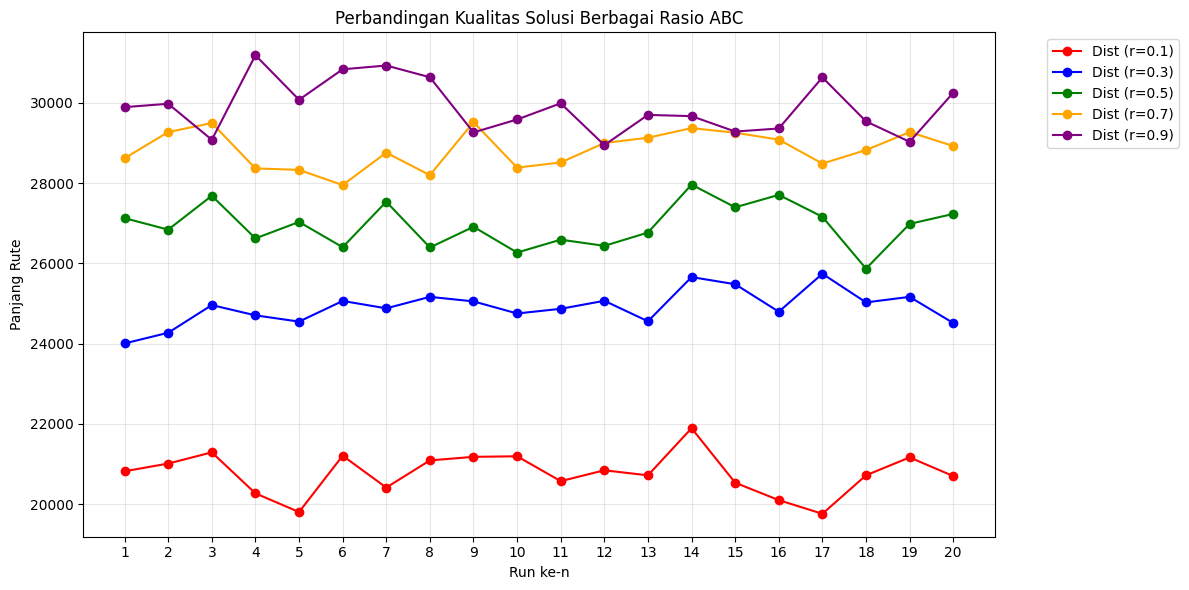

In [3]:
import numpy as np, networkx as nx, random, matplotlib.pyplot as plt, pandas as pd

# === GRAPH CREATION ===
def create_graph(n, seed):
    rng = random.Random(seed)
    G = nx.complete_graph(n)
    for u,v in G.edges(): 
        G[u][v]['weight'] = rng.randint(1,500)
    return G

# === CORE ===
def tour_len(G,t): return sum(G[t[i]][t[(i+1)%len(t)]]['weight'] for i in range(len(t)))
def fitness(G,t):  return 1/(1+tour_len(G,t))
def rand_tour(G):  return random.sample(list(G.nodes()),G.number_of_nodes())

# === INITIAL TEMPLATE (FIXED) ===
def init_template(G,SN):
    tours=[rand_tour(G) for _ in range(SN)]
    fits=[fitness(G,t) for t in tours]
    return tours,fits

# === PHASES ===
def employed_v2(G, bee_tours, bee_fits, bee_trials):
    n=len(bee_tours[0]); NSE=n//2

    for k in range(len(bee_tours)):
        original=bee_tours[k][:]
        old_fit=bee_fits[k]
        current=original[:]

        # === SWAP OPERATOR (tunggal) ===
        i,j=random.sample(range(n),2)
        current[i],current[j]=current[j],current[i]
        f=fitness(G,current)

        if f>old_fit:
            solusi_terpilih=current[:]
            fitness_terpilih=f
            bee_trials[k]=0
            base_for_sequence=current[:]
        else:
            solusi_terpilih=original[:]
            fitness_terpilih=old_fit
            bee_trials[k]+=1
            base_for_sequence=original[:]

        # === SWAP SEQUENCE ===
        current=base_for_sequence[:]
        best_seq=solusi_terpilih[:]
        best_seq_fit=fitness_terpilih

        for _ in range(NSE):
            a,b=random.sample(range(n),2)
            current[a],current[b]=current[b],current[a]
            f_seq=fitness(G,current)

            if f_seq>best_seq_fit:
                best_seq_fit=f_seq
                best_seq=current[:]

        if best_seq_fit>fitness_terpilih:
            bee_tours[k]=best_seq[:]
            bee_fits[k]=best_seq_fit
            bee_trials[k]=0
        else:
            bee_tours[k]=solusi_terpilih[:]
            bee_fits[k]=fitness_terpilih
            bee_trials[k]+=1

def onlooker_v2(G, bee_tours, bee_fits, bee_trials, N_onl):
    n = len(bee_tours[0])
    NSE = n//2
    NP_e = len(bee_tours)

    # Snapshot kondisi awal fase
    base_tours = [t[:] for t in bee_tours]
    base_fits = bee_fits[:]
    base_trials = bee_trials[:]

    # Inisialisasi penyimpan sementara dengan snapshot
    best_tours = [t[:] for t in base_tours]
    best_fits = base_fits[:]
    best_trials = base_trials[:]

    # Hitung probabilitas (berdasarkan snapshot)
    sum_fits = sum(base_fits)
    probs = [f / sum_fits for f in base_fits]
    cp = np.cumsum(probs)

    for _ in range(N_onl):
        r = random.random()
        i = next((j for j in range(NP_e) if r < cp[j]), NP_e - 1)

        original = base_tours[i][:]
        old_fit = base_fits[i]
        old_trial = base_trials[i]

        # --- Insert Operator ---
        a, b = random.sample(range(n), 2)
        candidate = original[:]
        candidate.insert(b, candidate.pop(a))
        fit_candidate = fitness(G, candidate)

        if fit_candidate > old_fit:
            solusi_terpilih = candidate[:]
            fitness_terpilih = fit_candidate
            trial_setelah_operator = 0
        else:
            solusi_terpilih = original[:]
            fitness_terpilih = old_fit
            trial_setelah_operator = old_trial + 1

        # --- Insert Sequence ---
        current = solusi_terpilih[:]
        best_seq = solusi_terpilih[:]
        best_seq_fit = fitness_terpilih

        for _ in range(NSE):
            a, b = random.sample(range(n), 2)
            current.insert(b, current.pop(a))
            f_seq = fitness(G, current)
            if f_seq > best_seq_fit:
                best_seq_fit = f_seq
                best_seq = current[:]

        if best_seq_fit > fitness_terpilih:
            solusi_final = best_seq[:]
            fitness_final = best_seq_fit
            trial_final = 0
        else:
            solusi_final = solusi_terpilih[:]
            fitness_final = fitness_terpilih
            trial_final = trial_setelah_operator + 1   # tambah karena sequence gagal

        # Simpan jika lebih baik dari kandidat sementara untuk employed bee i
        if fitness_final > best_fits[i]:
            best_tours[i] = solusi_final[:]
            best_fits[i] = fitness_final
            best_trials[i] = trial_final

    # Setelah semua onlooker, perbarui populasi dengan hasil terbaik
    for i in range(NP_e):
        bee_tours[i] = best_tours[i][:]
        bee_fits[i] = best_fits[i]
        bee_trials[i] = best_trials[i]

def scout(G, bee_tours, bee_fits, bee_trials, limit):
    for i in range(len(bee_tours)):
        if bee_trials[i]>=limit:
            bee_tours[i]=rand_tour(G)
            bee_fits[i]=fitness(G,bee_tours[i])
            bee_trials[i]=0

# === MAIN (static Qin, FIXED INITIAL) ===
def abc_qin_static(G, NP, limit, cycles, r_c, base_tours, base_fits):

    NP_e=round(r_c*NP); NP_o=NP-NP_e; SN=round(NP/2)

    if NP_e>=SN:
        perm=list(range(SN)); random.shuffle(perm)
        assign=perm+[random.randrange(SN) for _ in range(NP_e-SN)]
    else:
        assign=[random.randrange(SN) for _ in range(NP_e)]

    bee_tours=[base_tours[idx][:] for idx in assign]
    bee_fits=[base_fits[idx] for idx in assign]
    bee_trials=[0]*NP_e

    b_idx=np.argmax(bee_fits)
    b_fit,b_tour,f_best=bee_fits[b_idx],bee_tours[b_idx][:],0

    for c in range(1,cycles+1):

        if NP_e>0:
            employed_v2(G,bee_tours,bee_fits,bee_trials)

        if NP_o>0:
            onlooker_v2(G,bee_tours,bee_fits,bee_trials,NP_o)

        scout(G,bee_tours,bee_fits,bee_trials,limit)
        i=np.argmax(bee_fits)
        if bee_fits[i]>b_fit:
            b_fit,b_tour,f_best=bee_fits[i],bee_tours[i][:],c

    return tour_len(G,b_tour),f_best


# === EXPERIMENT & VISUALIZATION ===
if __name__=="__main__":

    seed_demo=62
    random.seed(seed_demo)
    n,seed,NP,limit,cycles,runs=200,43,80,20,50,20
    G=create_graph(n,seed)
    ratios=[0.1,0.3,0.5,0.7,0.9]
    colors=['red','blue','green','orange','purple']

    fig,ax1=plt.subplots(figsize=(12,6))
    all_dist={}

    SN=round(NP/2)
    base_tours,base_fits=init_template(G,SN)

    print(f"ABC Qin static | n={n}, NP={NP}, cycles={cycles}\n")
    records=[]

    for r,col in zip(ratios,colors):
        NP_e=round(r*NP); NP_o=NP-NP_e

        print(f"r_c={r:.1f} → NPₑ={NP_e}, NPₒ={NP_o}, SN={SN}")
        print(f"{'Run':<4}{'Panjang Jarak Terbaik':<22}{'Iterasi Optimal':<15}")
        print("-"*45)

        dist,itr=[],[]

        for k in range(1,runs+1):
            d,i=abc_qin_static(G,NP,limit,cycles,r,base_tours,base_fits)
            dist.append(d)
            itr.append(i)
            records.append([r,d,i])
            print(f"{k:<4}{d:<22.2f}{i:<15d}")
            
        ax1.plot(range(1,runs+1),dist,color=col,marker='o',label=f'Dist (r={r})')
        print("-"*45)
        print(f"Mean {np.mean(dist):.2f}\n")

    df=pd.DataFrame(records,columns=["Rasio","Total_Jarak_Terpendek","Iterasi_Optimal"])
    df.to_excel("hasil_ABC_Article_Version_Final_200_nodes_b1to500_50C_S62.xlsx",index=False)

    ax1.set_xlabel('Run ke-n')
    ax1.set_ylabel('Panjang Rute')
    ax1.set_title('Perbandingan Kualitas Solusi Berbagai Rasio ABC')
    ax1.grid(True,alpha=0.3)

    # === FIX 1: Pastikan sumbu X integer ===
    ax1.set_xticks(range(1, runs+1))
    ax1.legend(loc='upper left',bbox_to_anchor=(1.05,1))
    plt.tight_layout()
    plt.savefig("grafik_ABC_Qin_static_200.png", dpi=300, bbox_inches='tight')

    plt.show()